In [134]:
import pandas as pd
from sklearn.model_selection import train_test_split
import random
from sklearn import linear_model
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
from datetime import datetime

In [135]:
import sqlite3
try:
    sqliteConnection = sqlite3.connect('go_sales_train.sqlite')
    cursor = sqliteConnection.cursor()
    print('Db created and connected succesfull')
except sqlite3.Error as error:
    print('Error occured: ', error)

Db created and connected succesfull


In [136]:
sales_orderHeader = pd.read_sql("SELECT * FROM order_header", sqliteConnection)
sales_orderDetails = pd.read_sql("SELECT * FROM order_details", sqliteConnection)

table = pd.merge(sales_orderHeader, sales_orderDetails, left_on='ORDER_NUMBER', right_on='ORDER_NUMBER')
for index, row in table.iterrows():
    table.loc[index, 'ORDER_DATE'] = datetime.strptime(row['ORDER_DATE'], '%Y-%m-%d').month


# for index, row in table.iterrows():
#     date = datetime.strptime(row['ORDER_DATE'], '%Y-%m-%d')
#     table.loc[index, 'ORDER_DATE'] = date.strftime('%m/%Y')

table

,ORDER_NUMBER,RETAILER_NAME,RETAILER_SITE_CODE,RETAILER_CONTACT_CODE,SALES_STAFF_CODE,SALES_BRANCH_CODE,ORDER_DATE,ORDER_METHOD_CODE,ORDER_DETAIL_CODE,PRODUCT_NUMBER,QUANTITY,UNIT_COST,UNIT_PRICE,UNIT_SALE_PRICE
0,1153,Ultra Sports,4,6,50,18,4,7,47747,2,100,9.64,12.53,11.81
1,1153,Ultra Sports,4,6,50,18,4,7,47994,32,254,18.25,27.37,25.10
2,1153,Ultra Sports,4,6,50,18,4,7,48015,35,114,19.67,26.54,24.82
3,1153,Ultra Sports,4,6,50,18,4,7,48022,36,130,21.03,34.90,31.44
4,1153,Ultra Sports,4,6,50,18,4,7,48049,39,74,42.33,67.73,61.38
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37752,9479,Preben's T°y,338,329,27,15,2,5,110788,52,64,19.00,38.00,33.25
37753,9479,Preben's T°y,338,329,27,15,2,5,110816,56,24,9.00,18.00,15.75
37754,9479,Preben's T°y,338,329,27,15,2,5,110827,57,40,40.00,80.00,70.00
37755,9479,Preben's T°y,338,329,27,15,2,5,110914,78,32,79.19,99.00,94.05


In [137]:
table = table.loc[:, ['PRODUCT_NUMBER', 'QUANTITY', 'ORDER_DATE']]
table

,PRODUCT_NUMBER,QUANTITY,ORDER_DATE
0,2,100,4
1,32,254,4
2,35,114,4
3,36,130,4
4,39,74,4
...,...,...,...
37752,52,64,2
37753,56,24,2
37754,57,40,2
37755,78,32,2


In [138]:
# dummie_dataframe = pd.get_dummies(table.loc[:, ['ORDER_DATE']])
# dummie_dataframe

In [139]:
# df = pd.concat([table, dummie_dataframe], axis = 1)
# df = df.drop(['ORDER_DATE'], axis = 1)
# df = df.loc[:, ['Pclass', 'Sex_female', 'Sex_male', 'Age']]
# df

In [140]:
X = table.loc[table['QUANTITY'].notna(), :]
X = X.drop('QUANTITY', axis=1)
y = table.loc[table['QUANTITY'].notna(), ['QUANTITY']]
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 37757 entries, 0 to 37756
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   PRODUCT_NUMBER  37757 non-null  int64 
 1   ORDER_DATE      37757 non-null  object
dtypes: int64(1), object(1)
memory usage: 884.9+ KB


In [141]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.15,
    random_state=42
)

In [142]:
reg_model = linear_model.LinearRegression()
reg_model = LinearRegression().fit(X_train, y_train)
reg_model

LinearRegression()

In [143]:
y_pred= reg_model.predict(X_test)
y_pred

array([[57.1375875 ],
       [55.32235627],
       [47.0994265 ],
       ...,
       [57.21775457],
       [46.40464523],
       [43.97668882]], shape=(5664, 1))

In [144]:
prediction_df = pd.DataFrame(y_pred)
prediction_df = prediction_df.rename(columns = {0 : 'Predicted_Quantity'})
prediction_df

,Predicted_Quantity
0,57.137587
1,55.322356
2,47.099427
3,44.242023
4,42.560404
...,...
5659,55.240300
5660,48.914658
5661,57.217755
5662,46.404645


In [145]:
y_test_prediction_merge = pd.concat([y_test.reset_index()['QUANTITY'], prediction_df], axis = 1)
y_test_prediction_merge.loc[y_test_prediction_merge['Predicted_Quantity'].notna(), :]

,QUANTITY,Predicted_Quantity
0,4,57.137587
1,6,55.322356
2,66,47.099427
3,24,44.242023
4,70,42.560404
...,...,...
5659,64,55.240300
5660,16,48.914658
5661,12,57.217755
5662,36,46.404645


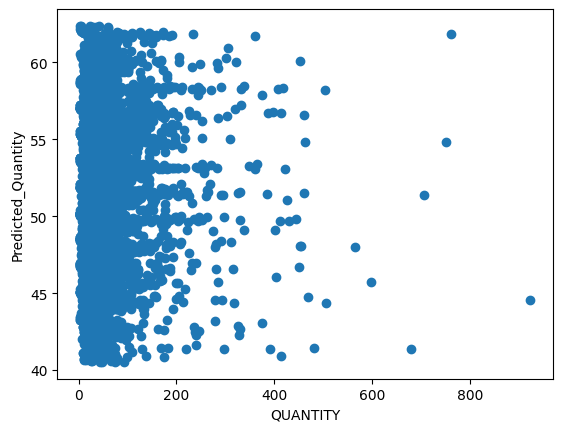

In [146]:
plt.scatter(y_test_prediction_merge['QUANTITY'], y_test_prediction_merge['Predicted_Quantity'])
plt.xlabel('QUANTITY')
plt.ylabel('Predicted_Quantity')
plt.show()

In [147]:
mean_squared_error(y_test_prediction_merge['QUANTITY'], y_test_prediction_merge['Predicted_Quantity'])

3583.7579354650434

In [148]:
mean_absolute_error(y_test_prediction_merge['QUANTITY'], y_test_prediction_merge['Predicted_Quantity'])

35.826909317111536